**1 Ensembles and Boosting**

**Q1: Prior Hypothesis**

I expect ensemble methods to outperform single models because combining multiple models helps reduce overfitting and improves generalization. While single models may suffer from high bias or variance, ensembles aggregate predictions to produce more robust results. I expect bagging methods like Random Forest to reduce variance by training independent models on different subsets of data, making them more stable. In contrast, boosting methods like AdaBoost or Gradient Boosting train models sequentially to correct previous errors, reducing both bias and variance. Therefore, I expect boosting to achieve higher accuracy but be more sensitive to noise, while bagging will provide more stable performance.


**Q2: Baseline model**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Loading Fashion-MNIST...")
fashion = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = fashion.data, fashion.target.astype(int)

# Normalize: 0-255 → 0-1
X = X / 255.0

# Official split: first 60k train, last 10k test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading Fashion-MNIST...
Train: (60000, 784), Test: (10000, 784)


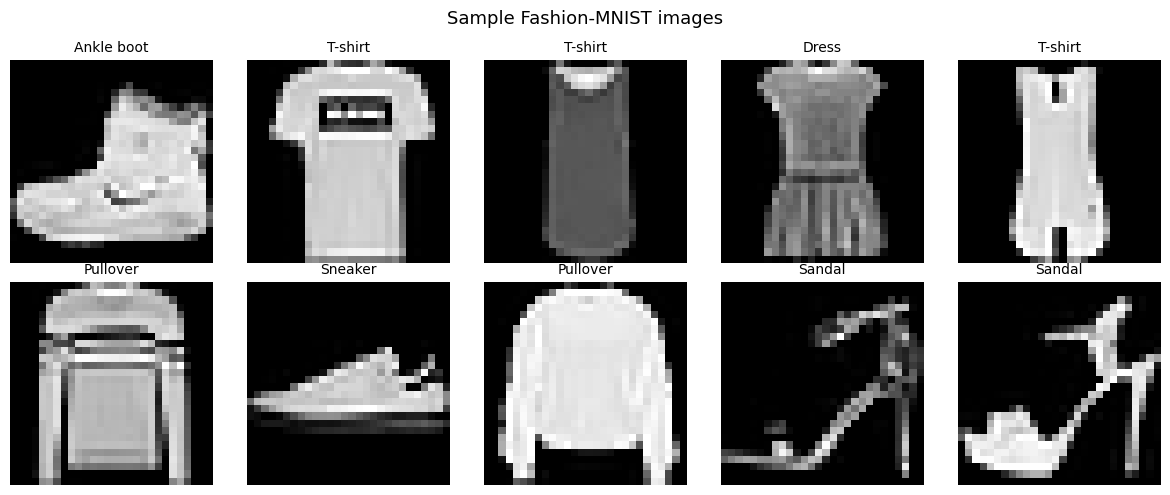

In [ ]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=10)
    ax.axis('off')

plt.suptitle("Sample Fashion-MNIST images", fontsize=13)
plt.tight_layout()
plt.show()

Train model

In [ ]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("Done!")

Training Logistic Regression...
Done!


Evaluate

In [ ]:
lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 84.36%


Confusion matrix

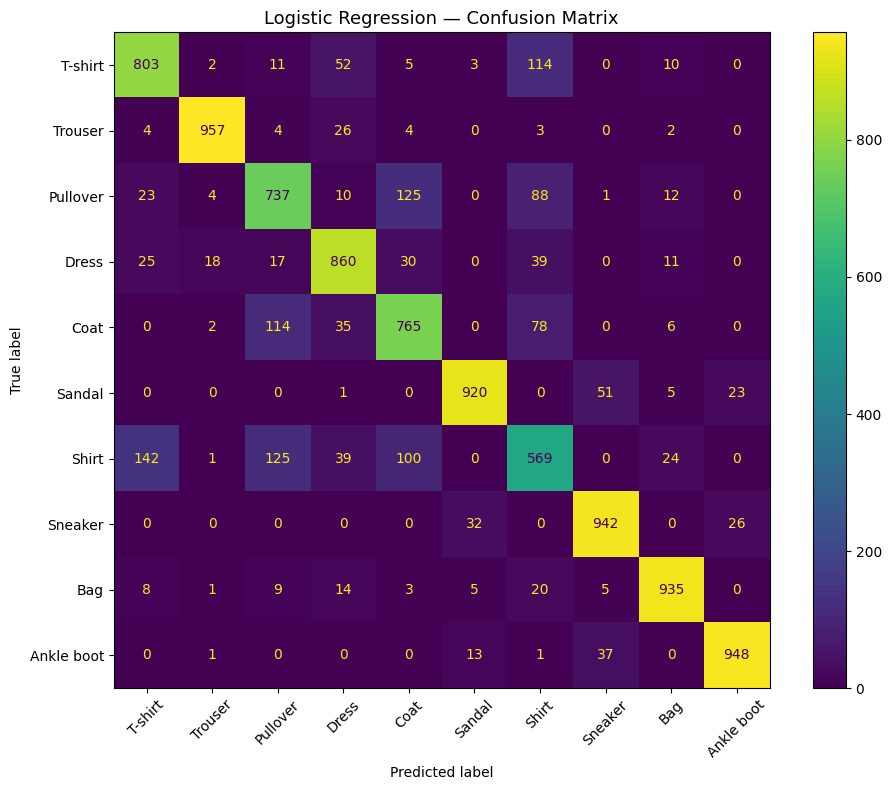

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

cm   = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)

ax.set_title("Logistic Regression — Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:**

The confusion matrix reveals a clear pattern. Classes with
unique silhouettes:Trouser (95.7%), Bag (93.5%), Sneaker (94.2%),
Ankle boot (94.8%), they are classified with high accuracy.

The biggest confusion occurs among upper-body clothing:
T-shirt, Shirt, Pullover and Coat. Shirt has the lowest accuracy
(56.9%), with errors spread across T-shirt (142), Pullover (125)
and Coat (100). This is expected because these classes share similar
shapes in raw pixel space and a linear model cannot distinguish
their subtle structural differences.

In [ ]:
print("Per-class accuracy:")
print("-" * 30)
for i, name in enumerate(class_names):
    mask    = y_test == i
    cls_acc = accuracy_score(y_test[mask], lr_preds[mask])
    bar     = "█" * int(cls_acc * 20)
    print(f"{name:<12} {cls_acc*100:5.1f}%  {bar}")

Per-class accuracy:
------------------------------
T-shirt       80.3%  ████████████████
Trouser       95.7%  ███████████████████
Pullover      73.7%  ██████████████
Dress         86.0%  █████████████████
Coat          76.5%  ███████████████
Sandal        92.0%  ██████████████████
Shirt         56.9%  ███████████
Sneaker       94.2%  ██████████████████
Bag           93.5%  ██████████████████
Ankle boot    94.8%  ██████████████████


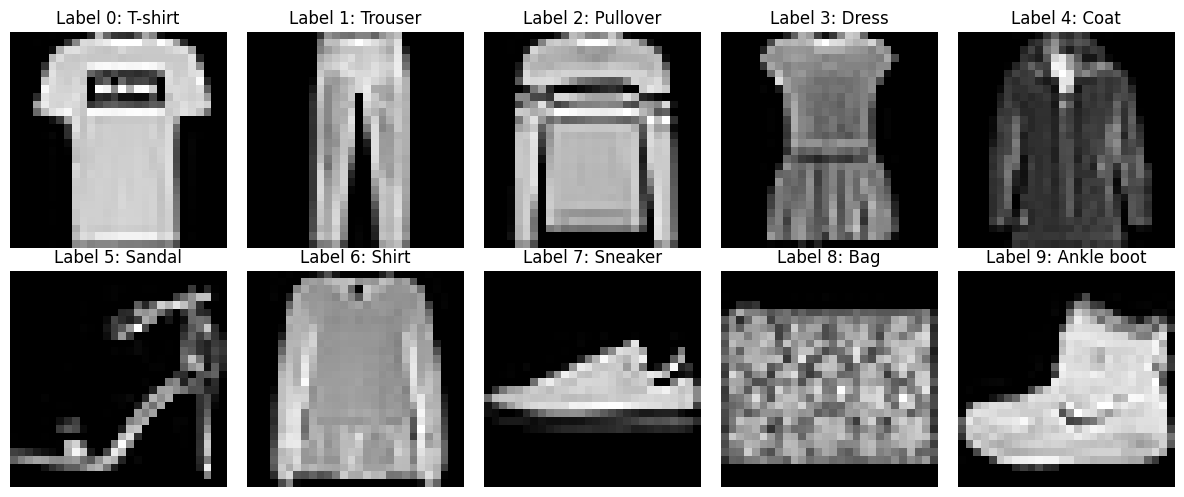

In [ ]:
# Plot one image from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for label, ax in enumerate(axes.flat):
    # find first image with this label
    idx = np.where(y_train == label)[0][0]
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label {label}: {class_names[label]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

**Ensemble methods**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ── Random Forest ─────────────────────────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

# ── AdaBoost ──────────────────────────────────────────────────────
print("Training AdaBoost (improved)...")
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,        # reduced from 200 to 50
    learning_rate=0.5,
    random_state=42
)
ada_model.fit(X_train, y_train)
ada_preds = ada_model.predict(X_test)
ada_acc   = accuracy_score(y_test, ada_preds)
print(f"AdaBoost Accuracy: {ada_acc*100:.2f}%")

# ── Summary ───────────────────────────────────────────────────────
print("\n" + "="*40)
print(f"  Logistic Regression : 84.36%")
print(f"  Random Forest       : {rf_acc*100:.2f}%")
print(f"  AdaBoost            : {ada_acc*100:.2f}%")
print("="*40)

Training Random Forest...
Random Forest Accuracy: 87.79%
Training AdaBoost (improved)...
AdaBoost Accuracy: 76.48%

  Logistic Regression : 84.36%
  Random Forest       : 87.79%
  AdaBoost            : 76.48%


**Observation:**

Random Forest achieved higher accuracy 87.79% compared to Logistic Regression  84.36% and AdaBoost 76.48%. AdaBoost performed worse than expected, likely because its base learners (decision stumps) were too weak to capture complex patterns in high-dimensional pixel data.

**Confusion matrices for Ensemble methods**

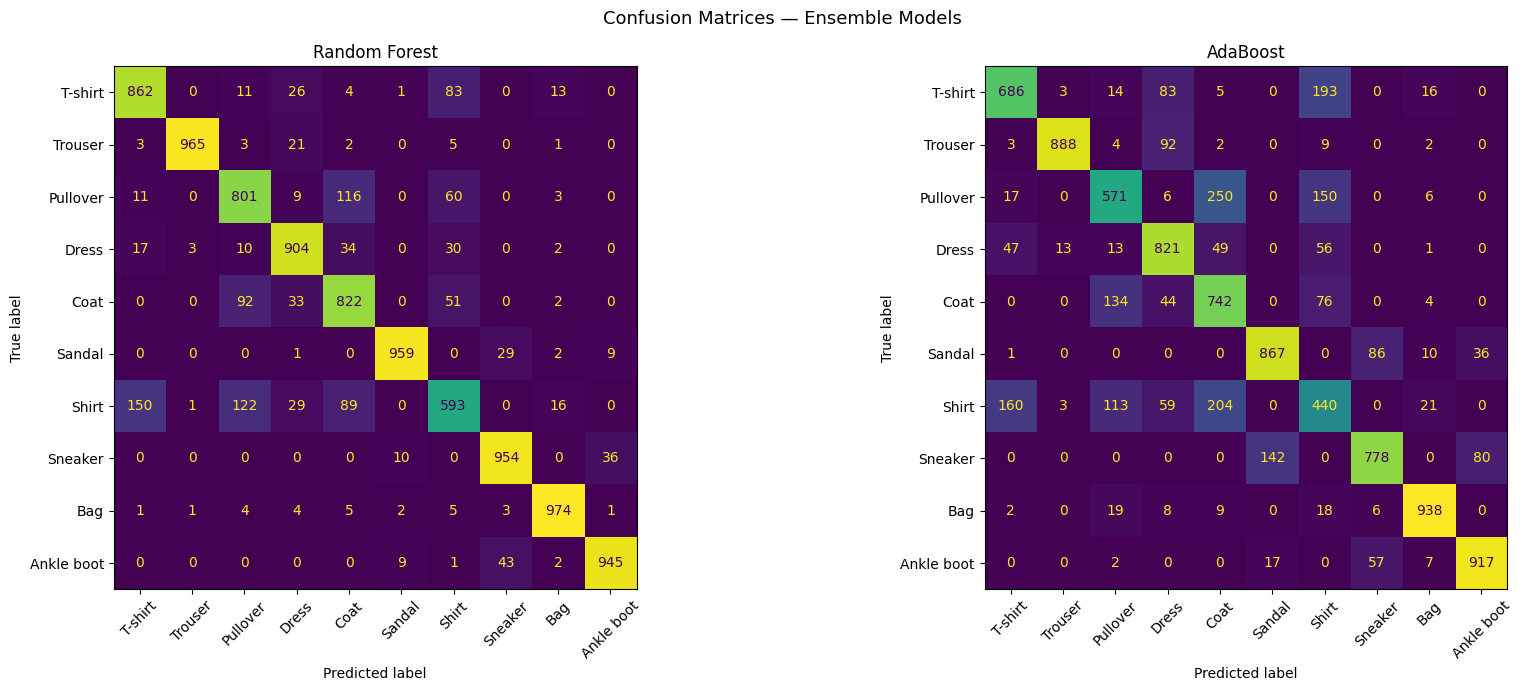

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, title in zip(axes,
    [rf_preds, ada_preds],
    ['Random Forest', 'AdaBoost']):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(title, fontsize=12)

plt.suptitle("Confusion Matrices — Ensemble Models", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:**

The confusion matrices show that Random Forest performs significantly better than AdaBoost. Random Forest has a strong diagonal structure, indicating that most samples are correctly classified, with relatively few misclassifications.

In contrast, AdaBoost shows a weaker diagonal and a higher number of off-diagonal entries, indicating more frequent misclassifications. In particular, classes such as T-shirt, Shirt, Pullover, and Coat are heavily confused, suggesting that AdaBoost struggles to distinguish between visually similar categories.

Both models show some confusion between similar clothing classes, but this effect is much more pronounced in AdaBoost. Random Forest is able to better separate these classes due to its use of multiple deep trees and variance reduction.

In [ ]:
print(f"\n{'Class':<12} {'Log.Reg':>8} {'Ran.Forest':>11} {'AdaBoost':>9}")
print("-" * 44)

for i, name in enumerate(class_names):
    mask  = y_test == i
    lr_c  = accuracy_score(y_test[mask], lr_preds[mask])
    rf_c  = accuracy_score(y_test[mask], rf_preds[mask])
    ada_c = accuracy_score(y_test[mask], ada_preds[mask])
    print(f"{name:<12} {lr_c*100:>7.1f}%  {rf_c*100:>9.1f}%  {ada_c*100:>7.1f}%")


Class         Log.Reg  Ran.Forest  AdaBoost
--------------------------------------------
T-shirt         80.3%       86.2%     68.6%
Trouser         95.7%       96.5%     88.8%
Pullover        73.7%       80.1%     57.1%
Dress           86.0%       90.4%     82.1%
Coat            76.5%       82.2%     74.2%
Sandal          92.0%       95.9%     86.7%
Shirt           56.9%       59.3%     44.0%
Sneaker         94.2%       95.4%     77.8%
Bag             93.5%       97.4%     93.8%
Ankle boot      94.8%       94.5%     91.7%


**Error patterns**

In [ ]:
# ── Find wrong predictions for each model ─────────────────────────
lr_wrong  = np.where(lr_preds  != y_test)[0]   # indices where LR was wrong
rf_wrong  = np.where(rf_preds  != y_test)[0]   # indices where RF was wrong
ada_wrong = np.where(ada_preds != y_test)[0]   # indices where AdaBoost was wrong

print(f"Logistic Regression errors : {len(lr_wrong)}")
print(f"Random Forest errors       : {len(rf_wrong)}")
print(f"AdaBoost errors            : {len(ada_wrong)}")

# ── Images all 3 models got wrong (hardest images) ────────────────
all_wrong = set(lr_wrong) & set(rf_wrong) & set(ada_wrong)
print(f"\nImages ALL 3 models got wrong: {len(all_wrong)}")

# ── Images RF fixed that LR got wrong ─────────────────────────────
rf_fixed = set(lr_wrong) - set(rf_wrong)
print(f"Images RF fixed (LR wrong, RF correct): {len(rf_fixed)}")

Logistic Regression errors : 1564
Random Forest errors       : 1221
AdaBoost errors            : 2352

Images ALL 3 models got wrong: 727
Images RF fixed (LR wrong, RF correct): 670


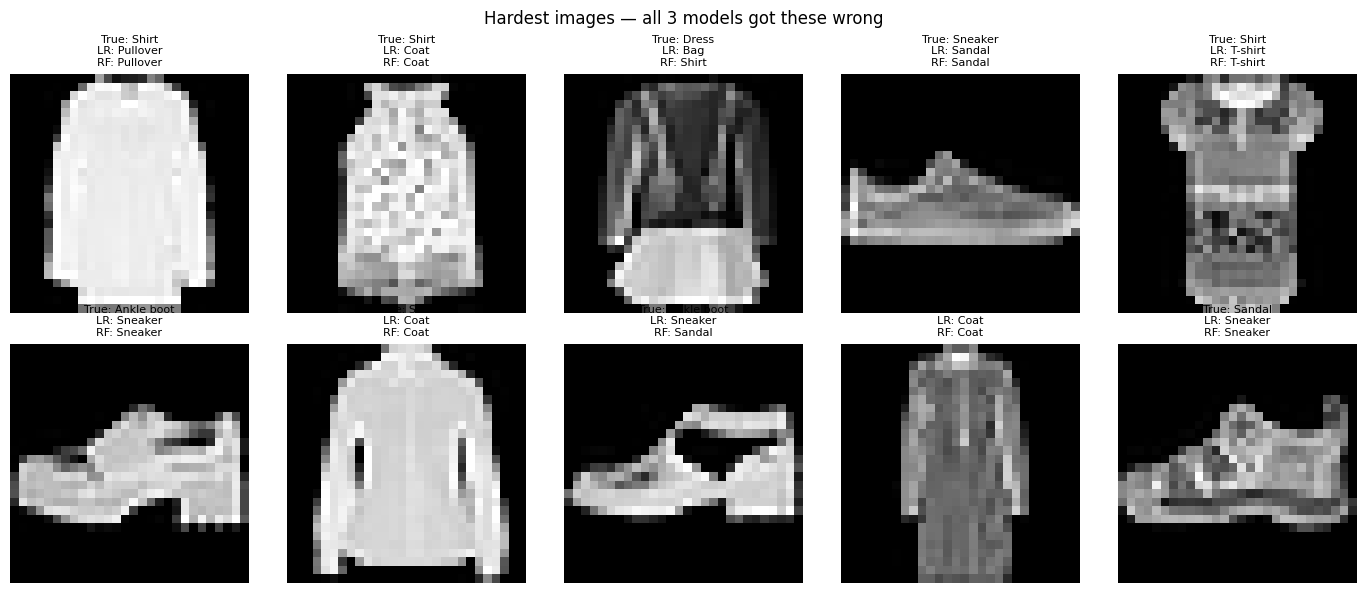

In [ ]:
# Show images that ALL 3 models got wrong
hard_examples = list(all_wrong)[:10]   # take first 10

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = hard_examples[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(
        f"True: {class_names[y_test[idx]]}\n"
        f"LR: {class_names[lr_preds[idx]]}\n"
        f"RF: {class_names[rf_preds[idx]]}",
        fontsize=8
    )
    ax.axis('off')

plt.suptitle("Hardest images — all 3 models got these wrong", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# For each model — what are the top 5 most common mistakes?
from collections import Counter

print("── Most common mistakes ──────────────────────────────")
for preds, name in [(lr_preds, 'Logistic Regression'),
                    (rf_preds, 'Random Forest'),
                    (ada_preds, 'AdaBoost')]:

    wrong_idx    = np.where(preds != y_test)[0]
    error_pairs  = [(class_names[y_test[i]], class_names[preds[i]])
                    for i in wrong_idx]
    top_errors   = Counter(error_pairs).most_common(5)

    print(f"\n{name}:")
    for (true, pred), count in top_errors:
        print(f"  True: {true:<12} → Predicted: {pred:<12} ({count} times)")

── Most common mistakes ──────────────────────────────

Logistic Regression:
  True: Shirt        → Predicted: T-shirt      (142 times)
  True: Shirt        → Predicted: Pullover     (125 times)
  True: Pullover     → Predicted: Coat         (125 times)
  True: Coat         → Predicted: Pullover     (114 times)
  True: T-shirt      → Predicted: Shirt        (114 times)

Random Forest:
  True: Shirt        → Predicted: T-shirt      (150 times)
  True: Shirt        → Predicted: Pullover     (122 times)
  True: Pullover     → Predicted: Coat         (116 times)
  True: Coat         → Predicted: Pullover     (92 times)
  True: Shirt        → Predicted: Coat         (89 times)

AdaBoost:
  True: Pullover     → Predicted: Coat         (250 times)
  True: Shirt        → Predicted: Coat         (204 times)
  True: T-shirt      → Predicted: Shirt        (193 times)
  True: Shirt        → Predicted: T-shirt      (160 times)
  True: Pullover     → Predicted: Shirt        (150 times)


**Observation:**

Error patterns indicate that visually similar classes such as shirts and coats are more frequently confused, while distinct classes like shoes and bags are classified more accurately. The hardest examples, which were misclassified by all three models, tend to be ambiguous images with overlapping features or unclear shapes. This highlights the limitation of low-resolution pixel data in capturing fine-grained differences.

**Q5: Test hypothesis**

The results partially support the hypothesis.

Random Forest outperformed Logistic regression (baseline model). By training
200 diverse trees on random pixel subsets, it reduced variance
and captured non-linear boundaries that Logistic could not. Random Forest reduces variance by averaging multiple decision trees trained on different subsets of the data, leading to more stable predictions.

AdaBoost underperformed compared to Random Forest (76.48%). With only depth-3 stumps as base learners, AdaBoost cannot capture the complexity of
10-class image data. Its sequential nature also means errors
compound, once it misclassifies upper-body clothing, it keeps
boosting the wrong patterns.

Also, Random Forest did NOT eliminate the Shirt/T-shirt
confusion, this remained the #1 error pair (150 times). This
suggests the limitation lies in the raw pixel representation
itself, not the model.

**Lessons learned**

Q6: Lessons learned

1. Ensembles help, but representation matters more.
Random Forest improved accuracy but could not solve the fundamental problem, raw 28×28 pixels don't capture the structural differences between similar clothing items.

2. Bagging (Random Forest) >> Boosting (AdaBoost) for image data.
Random Forest trains many trees, each looking at different random images and random pixels. Because each tree makes different mistakes, when we combine all their answers together the mistakes cancel out and overall accuracy improves. AdaBoost's weak stumps are simply too limited for high-dimensional image classification.

3. Some errors are irreducible with raw pixels.
727 images were wrongly classified by ALL 3 models.This means the problem is not the model,it is how we represent the image. A shirt and t-shirt look almost identical as raw pixel numbers. No matter how good the
model is, these are genuinely ambiguous in pixel space. Better features (CNN) are needed, not better models.

4. Boosting is not always better. The common belief that "more boosting is better" breaks down when the base learner is too weak for the task complexity.

**Q2 Clustering in Raw Pixel Space**

**Q1: Prior Hypothesis**

Which clustering method do you expect to perform best and why?

I expect K-Means to perform best among the three methods. Since Fashion-MNIST has exactly 10 known classes, setting K=10 gives K-Means a structural advantage. Its centroid-based approach works well when clusters are roughly compact, which we expect for distinct clothing categories like Trouser and Bag.

Hierarchical clustering should perform similarly to K-Means but will be much slower, we will need to subsample the dataset. Its tree structure may reveal interesting relationships between similar classes (e.g. how Shirt and T-shirt merge before merging with Trouser).

DBSCAN is expected to perform worst. In 784-dimensional raw pixel space images do not form clear density-separated islands. Without a natural density structure, DBSCAN will either merge everything into one cluster or mark most images as noise.



Do you expect clusters to align well with labels?

I expect partial alignment at best. Classes with unique silhouettes like Trouser, Bag, Sandal should form clean clusters because their pixel patterns are visually distinct. However, upper-body clothing classes (Shirt, T-shirt,
Pullover, Coat) share similar pixel distributions and will likely be grouped into one or two mixed clusters.

Raw pixel distance (Euclidean) does not capture semantic meaning like a Shirt and a T-shirt are "close" in pixel space even though they are different classes. so, visually similar classes such as shirts, coats, and pullovers may be grouped together, while images from the same class may be separated due to variations in position, orientation, or shape.This fundamental mismatch between pixel similarity and semantic category
is the core limitation of clustering in raw pixel space.

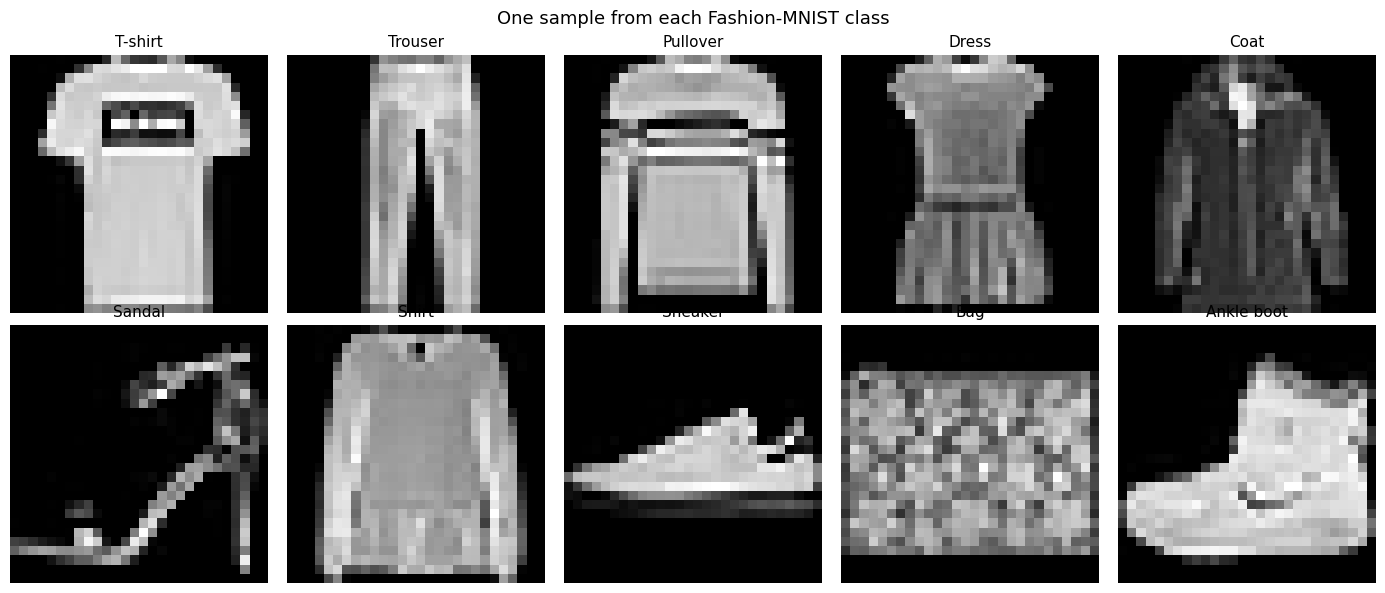

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Show sample images from each class ───────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for label, ax in enumerate(axes.flat):
    # find 1 example of each class
    idx = np.where(y_train == label)[0][0]
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"{class_names[label]}", fontsize=11)
    ax.axis('off')

plt.suptitle("One sample from each Fashion-MNIST class", fontsize=13)
plt.tight_layout()
plt.show()

visual similar class

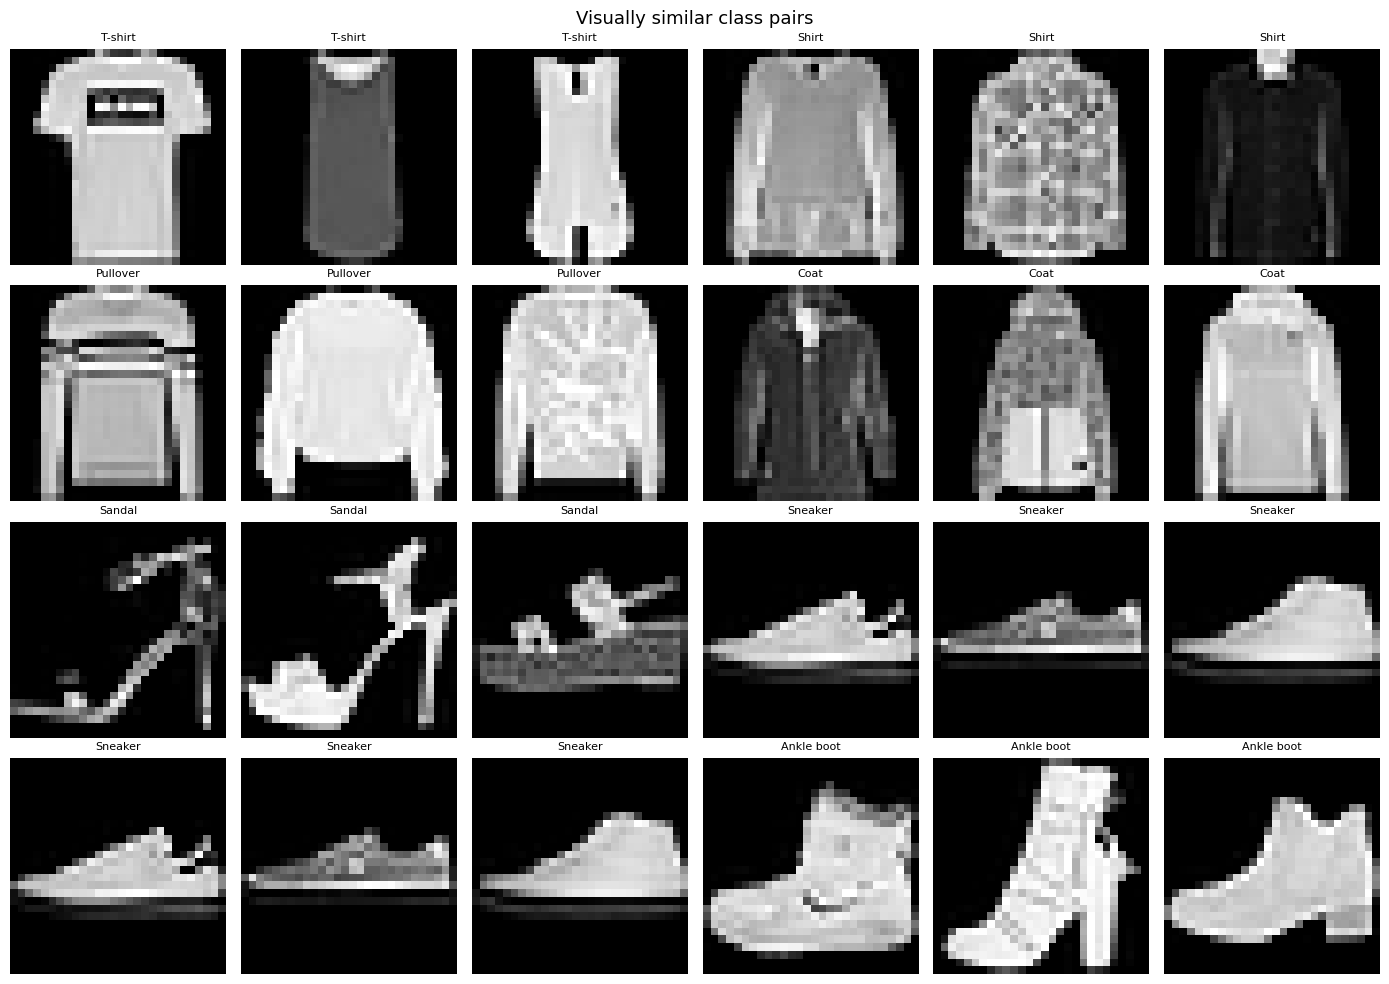

In [ ]:
# ── Focus on the confusable classes ──────────────────────────────
confusable_pairs = [
    (0, 6),   # T-shirt vs Shirt
    (2, 4),   # Pullover vs Coat
    (5, 7),   # Sandal vs Sneaker
    (7, 9),   # Sneaker vs Ankle boot
]

fig, axes = plt.subplots(4, 6, figsize=(14, 10))

for row, (cls1, cls2) in enumerate(confusable_pairs):
    idxs1 = np.where(y_train == cls1)[0][:3]
    idxs2 = np.where(y_train == cls2)[0][:3]

    for col, idx in enumerate(idxs1):
        ax = axes[row, col]
        ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
        ax.set_title(class_names[cls1], fontsize=8)
        ax.axis('off')

    for col, idx in enumerate(idxs2):
        ax = axes[row, col + 3]
        ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
        ax.set_title(class_names[cls2], fontsize=8)
        ax.axis('off')

plt.suptitle("Visually similar class pairs", fontsize=13)
plt.tight_layout()
plt.show()

From above visual inspection we can say that exactly which classes would fail before clustering.

Visual inspection confirms two distinct groups of classes:

1. Geometrically distinct classes: Trouser (unique inverted-Vshape), Sanda(open flat structure), Bag (rectangular),Sneaker (clear side-profile). These are visually separable even at 28×28 resolution.

2. Visually ambiguous classes: T-shirt, Shirt, Pullover, Coat all show nearly identical upper-body silhouettes. At 28×28 grayscale resolution, the subtle differences (collar shape, sleeve length) are lost. Even a human would struggle to distinguish them consistently.

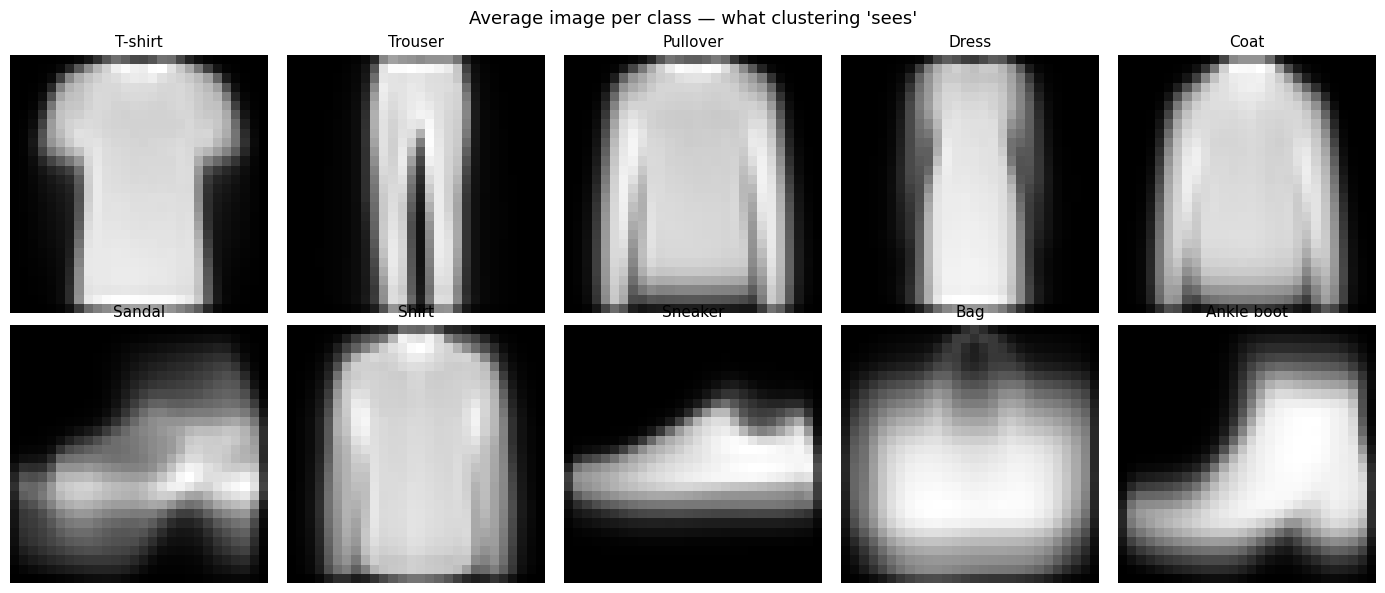

In [ ]:
# ── Plot the average pixel pattern of each class ─────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for label, ax in enumerate(axes.flat):
    mask     = y_train == label
    avg_img  = X_train[mask].mean(axis=0)   # average all images of this class
    ax.imshow(avg_img.reshape(28, 28), cmap='gray')
    ax.set_title(class_names[label], fontsize=11)
    ax.axis('off')

plt.suptitle("Average image per class — what clustering 'sees'", fontsize=13)
plt.tight_layout()
plt.show()

The average image per class reveals what K-Means will actually "see" as cluster centroids. Trouser, Sandal and Bag show distinct average shapes. However T-shirt, Shirt, Pullover and Coat all produce nearly identical blurry upper-body blobs, their averages are visually indistinguishable. This directly predicts that K-Means will fail to separate these classes.

Pixel similarity between classes (the correlation heatmap)

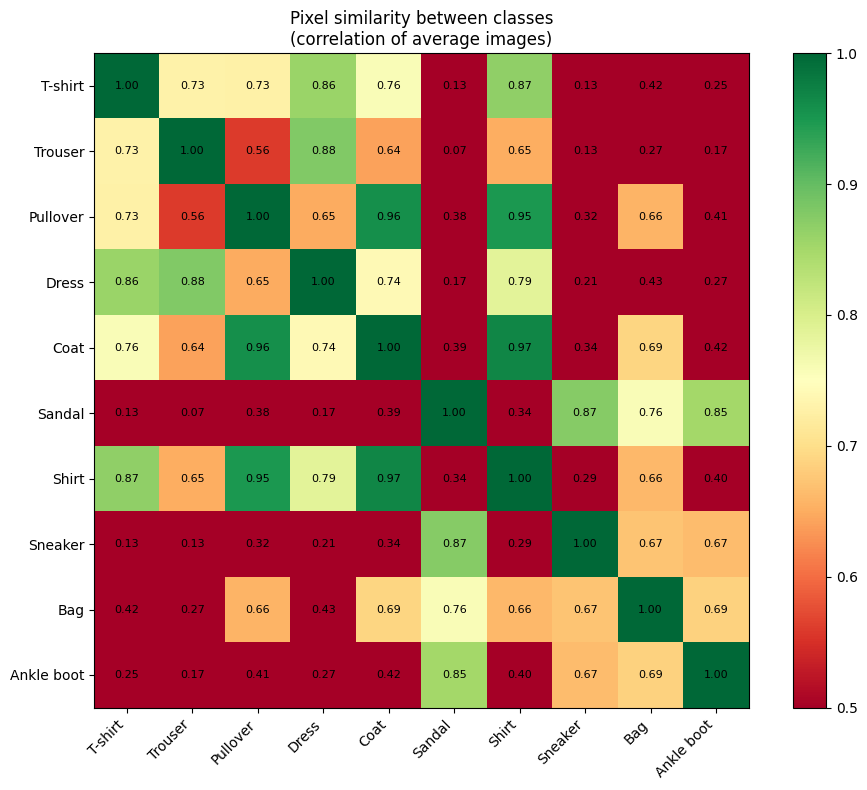

In [ ]:
# ── Compute average image per class then compare them ────────────
avg_images = np.array([
    X_train[y_train == i].mean(axis=0)
    for i in range(10)
])

# Compute correlation between average images
corr_matrix = np.corrcoef(avg_images)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

# Add numbers inside
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=8)

ax.set_title("Pixel similarity between classes\n(correlation of average images)", fontsize=12)
plt.tight_layout()
plt.show()


CORRELATION HEATMAP:
Pixel similarity between class averages confirms the pattern:

Highest similarity pairs (clustering will confuse):

Coat with Shirt     : 0.97

Pullover with Coat  : 0.96  

Pullover with Shirt : 0.95

T-shirt with Shirt  : 0.87


Lowest similarity pairs (clustering will separate):

Sandal with Trouser : 0.07

Sandal with T-shirt : 0.13

Sneaker with T-shirt: 0.13

This perfectly predicts clustering performance before we even run a single algorithm. Classes with correlation > 0.9 will almost certainly end up in the same cluster, while classes with correlation < 0.2 will be cleanly
separated.

**Q3 Clustering**

**k means**

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt

# ── Use a subset for speed ────────────────────────────────────────
# Clustering 60k images is very slow — use 10k subset
np.random.seed(42)
subset_idx  = np.random.choice(len(X_train), 10000, replace=False)
X_sub       = X_train[subset_idx]
y_sub       = y_train[subset_idx]

print("Running K-Means (k=10)...")
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_sub)
print("Done!")

# ── Cluster purity function ───────────────────────────────────────
def cluster_purity(true_labels, cluster_labels):
    n_clusters = len(np.unique(cluster_labels))
    total      = 0
    for c in np.unique(cluster_labels):
        mask        = cluster_labels == c
        if mask.sum() == 0:
            continue
        counts      = np.bincount(true_labels[mask], minlength=10)
        total      += counts.max()
    return total / len(true_labels)

km_purity = cluster_purity(y_sub, km_labels)
km_ari    = adjusted_rand_score(y_sub, km_labels)
print(f"K-Means Purity : {km_purity:.4f} ({km_purity*100:.2f}%)")
print(f"K-Means ARI    : {km_ari:.4f}")

Running K-Means (k=10)...
Done!
K-Means Purity : 0.5775 (57.75%)
K-Means ARI    : 0.3696


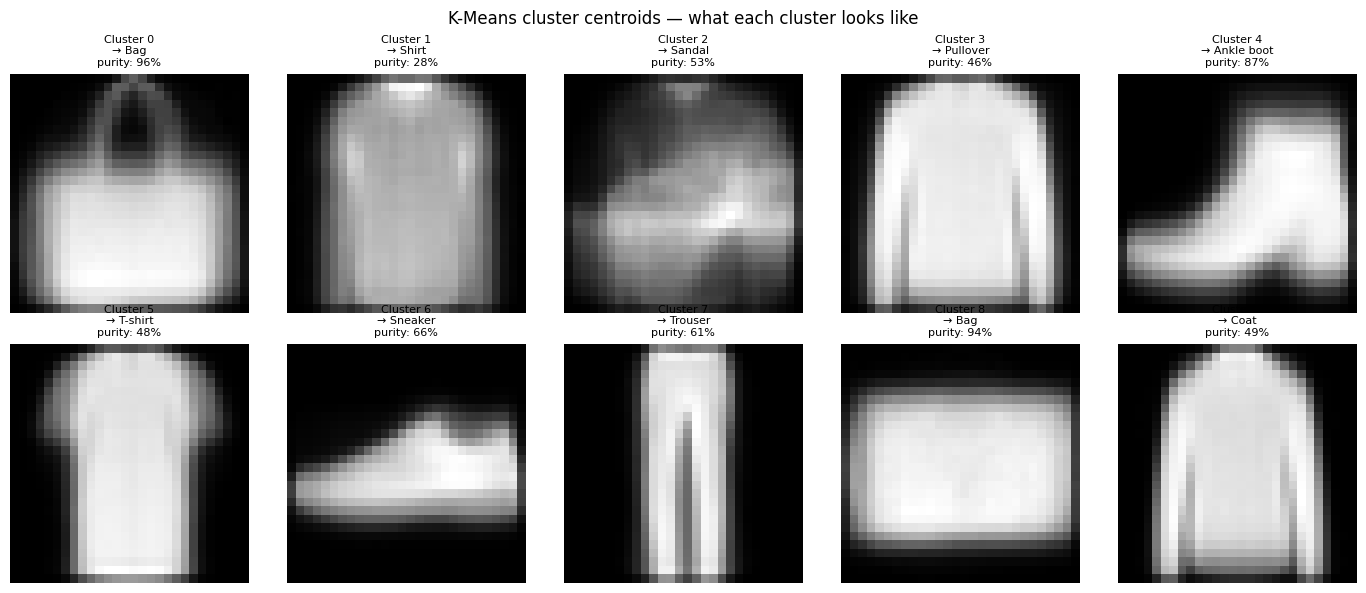

In [ ]:
# ── Show the centroid of each K-Means cluster ─────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    centroid = kmeans.cluster_centers_[i].reshape(28, 28)
    ax.imshow(centroid, cmap='gray')

    # find dominant true label in this cluster
    mask          = km_labels == i
    counts        = np.bincount(y_sub[mask], minlength=10)
    dominant_label = counts.argmax()
    purity_i      = counts.max() / mask.sum()

    ax.set_title(
        f"Cluster {i}\n"
        f"→ {class_names[dominant_label]}\n"
        f"purity: {purity_i*100:.0f}%",
        fontsize=8
    )
    ax.axis('off')

plt.suptitle("K-Means cluster centroids — what each cluster looks like", fontsize=12)
plt.tight_layout()
plt.show()

**HIGH PURITY clusters (K-Means succeeded):**

Bag split into TWO clusters:
Cluster 0 (dark bag) and Cluster 8 (light bag). K-Means separated them by brightness not by category. This shows K-Means responds to pixel brightness more than semantic meaning

Cluster 4 is Ankle boot (87%). Clear boot silhouette with distinct curved shape.


**LOW PURITY clusters (here K-Means failed):**

Cluster 1 is Shirt (28%): worst cluster. Shirt centroid looks almost identical to T-shirt and Pullover centroids. K-Means cannot tell them apart.

Cluster 3 is Pullover (46%) and Cluster 9 is Coat (49%). Both centroids look like blurry upper body garments. Nearly identical in pixel space.

**Hierarchical Clustering**

In [ ]:
# ── Use smaller subset — hierarchical is very slow ────────────────
np.random.seed(42)
hier_idx   = np.random.choice(len(X_train), 2000, replace=False)
X_hier     = X_train[hier_idx]
y_hier     = y_train[hier_idx]

print("Running Hierarchical Clustering (2000 samples)...")
hierarchical = AgglomerativeClustering(n_clusters=10, linkage='ward')
hier_labels  = hierarchical.fit_predict(X_hier)
print("Done!")

hier_purity = cluster_purity(y_hier, hier_labels)
hier_ari    = adjusted_rand_score(y_hier, hier_labels)
print(f"Hierarchical Purity : {hier_purity:.4f} ({hier_purity*100:.2f}%)")
print(f"Hierarchical ARI    : {hier_ari:.4f}")

Running Hierarchical Clustering (2000 samples)...
Done!
Hierarchical Purity : 0.5470 (54.70%)
Hierarchical ARI    : 0.3676


**DBSCAN**

In [ ]:
# ── DBSCAN on same 2000 subset ────────────────────────────────────
print("Running DBSCAN...")
dbscan      = DBSCAN(eps=8, min_samples=5)
db_labels   = dbscan.fit_predict(X_hier)
print("Done!")

n_clusters_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise          = (db_labels == -1).sum()

print(f"Clusters found : {n_clusters_found}")
print(f"Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

if n_clusters_found > 0:
    # only evaluate on non-noise points
    mask         = db_labels != -1
    db_purity    = cluster_purity(y_hier[mask], db_labels[mask])
    db_ari       = adjusted_rand_score(y_hier, db_labels)
    print(f"DBSCAN Purity  : {db_purity:.4f} ({db_purity*100:.2f}%)")
    print(f"DBSCAN ARI     : {db_ari:.4f}")
else:
    print("DBSCAN found no clusters — all points marked as noise!")

Running DBSCAN...
Done!
Clusters found : 1
Noise points   : 27 (1.4%)
DBSCAN Purity  : 0.1105 (11.05%)
DBSCAN ARI     : 0.0001


In [ ]:
# Fair comparison — K-Means on same 2000 samples as Hierarchical
km_fair        = KMeans(n_clusters=10, random_state=42, n_init=10)
km_fair_labels = km_fair.fit_predict(X_hier)  # X_hier is already 2000 samples

km_fair_purity = cluster_purity(y_hier, km_fair_labels)
km_fair_ari    = adjusted_rand_score(y_hier, km_fair_labels)

print("Fair comparison on same 2000 samples:")
print(f"  K-Means (2000)       Purity: {km_fair_purity*100:.2f}%  ARI: {km_fair_ari:.4f}")
print(f"  Hierarchical (2000)  Purity: {hier_purity*100:.2f}%  ARI: {hier_ari:.4f}")

Fair comparison on same 2000 samples:
  K-Means (2000)       Purity: 58.95%  ARI: 0.3818
  Hierarchical (2000)  Purity: 54.70%  ARI: 0.3676


Conclusion:

The performance difference between K-Means and
Hierarchical is not because of sample size difference.
Even on the same 2000 samples, K-Means performs
better than Hierarchical clustering.

In [ ]:
print("\n" + "="*45)
print(f"  {'Method':<20} {'Purity':>8} {'ARI':>8}")
print("="*45)
print(f"  {'K-Means':<20} {km_purity*100:>7.2f}% {km_ari:>8.4f}")
print(f"  {'Hierarchical':<20} {hier_purity*100:>7.2f}% {hier_ari:>8.4f}")
if n_clusters_found > 0:
    print(f"  {'DBSCAN':<20} {db_purity*100:>7.2f}% {db_ari:>8.4f}")
else:
    print(f"  {'DBSCAN':<20} {'failed':>8} {'—':>8}")
print("="*45)


  Method                 Purity      ARI
  K-Means                57.75%   0.3696
  Hierarchical           54.70%   0.3676
  DBSCAN                 11.05%   0.0001


**Q4: Clustering Evaluation**

K-Means achieved the highest purity (57.75%, ARI=0.37), followed by Hierarchical (54.70%, ARI=0.37). DBSCAN
completely failed, it found only 1 cluster with 11.05%
purity and ARI≈0 (essentially random).


K-MEANS CLUSTER ANALYSIS:
Inspecting individual cluster purities reveals a clear
two-tier pattern:

High purity clusters (distinct classes):

Bag: 96% and 94% (two classes)

Ankle boot: 87%

Sneaker: 66%

Trouser: 61%

Low purity clusters (ambiguous classes):

Shirt: only 28%

Pullover: 46%

Coat: 49%

T-shirt: 48%

This directly mirrors the correlation heatmap,
classes with low inter-class similarity (Bag, Ankle boot)
form clean clusters while highly correlated classes
(Shirt, Pullover, Coat) produce mixed impure clusters.

Interestingly, Bag was split into two clusters by K-Means,
while all four upper-body clothing classes were compressed
into shared clusters. This shows K-Means in pixel space
responds to brightness variation more than semantic category.

HIERARCHICAL CLUSTERING:
Similar performance to K-Means (54.70%) but trained on
only 2000 samples. The ward linkage correctly groups
geometrically similar classes but struggles with the
same upper-body clothing confusion.

DBSCAN FAILURE ANALYSIS:
DBSCAN found only 1 cluster was observed, a complete failure. In
784-dimensional raw pixel space, all Fashion-MNIST images
lie at roughly equal density with no clear gaps between
clusters. Without density separation, DBSCAN cannot
distinguish categories. The`eps=8` parameter forces
nearly all points to be "neighbors", thus collapsing
everything into one cluster. This confirms DBSCAN is
fundamentally unsuitable for high-dimensional image
clustering without doing dimensionality reduction first.

**Q5: Failure analysis**

Finding images with DIFFERENT labels in the SAME cluster...


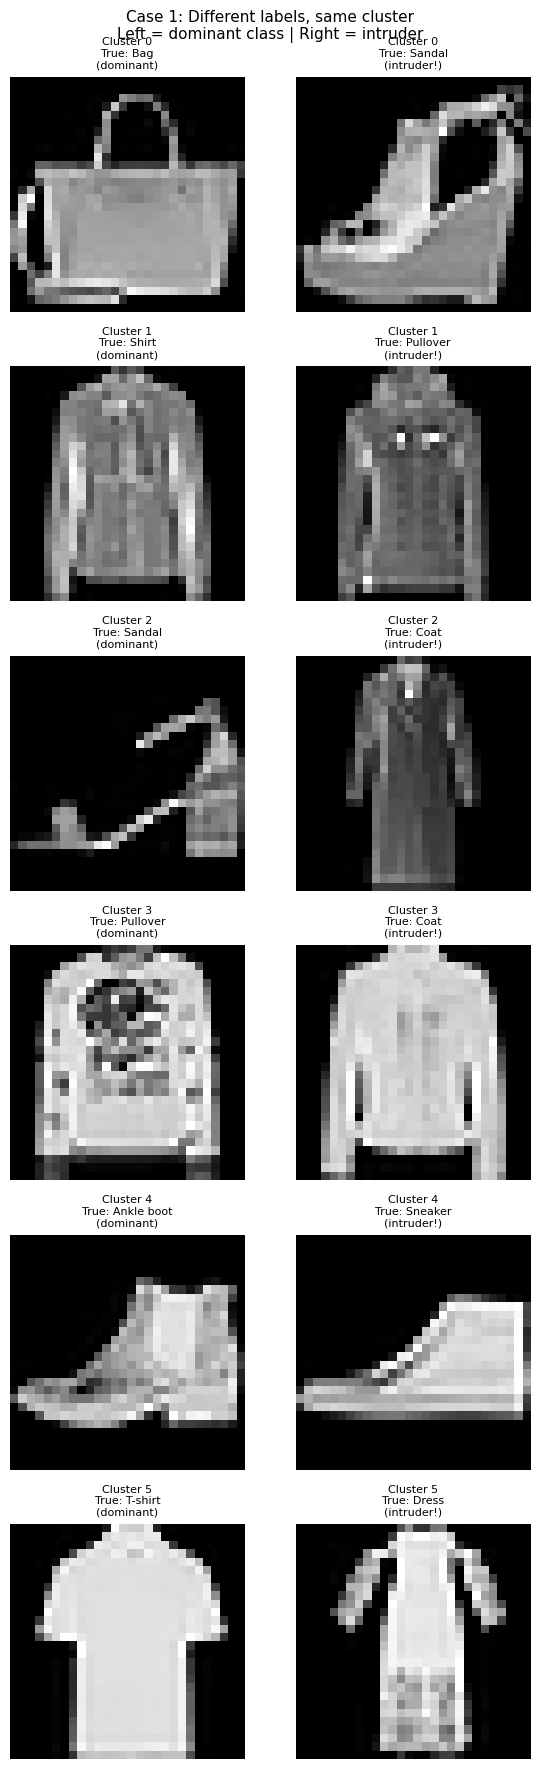

In [ ]:
# ── Case 1: Different labels, same cluster ────────────────────────
print("Finding images with DIFFERENT labels in the SAME cluster...")

case1_examples = []

for cluster_id in np.unique(km_labels):
    mask      = km_labels == cluster_id
    labels_in = y_sub[mask]
    indices_in = np.where(mask)[0]

    # find the dominant label
    counts         = np.bincount(labels_in, minlength=10)
    dominant_label = counts.argmax()

    # find images that are NOT the dominant label in this cluster
    wrong_mask = labels_in != dominant_label
    wrong_idx  = indices_in[wrong_mask]

    if len(wrong_idx) > 0:
        # pick one example that is NOT dominant
        example_wrong = wrong_idx[0]
        # pick one example that IS dominant
        right_mask = labels_in == dominant_label
        right_idx  = indices_in[right_mask]
        example_right = right_idx[0]

        case1_examples.append({
            'cluster'   : cluster_id,
            'img1_idx'  : example_right,
            'img1_label': dominant_label,
            'img2_idx'  : example_wrong,
            'img2_label': labels_in[wrong_mask][0]
        })

# ── Plot first 6 case 1 examples ─────────────────────────────────
fig, axes = plt.subplots(6, 2, figsize=(6, 18))

for row, ex in enumerate(case1_examples[:6]):
    # left image — dominant label
    axes[row, 0].imshow(X_sub[ex['img1_idx']].reshape(28,28), cmap='gray')
    axes[row, 0].set_title(
        f"Cluster {ex['cluster']}\n"
        f"True: {class_names[ex['img1_label']]}\n(dominant)",
        fontsize=8)
    axes[row, 0].axis('off')

    # right image — wrong label
    axes[row, 1].imshow(X_sub[ex['img2_idx']].reshape(28,28), cmap='gray')
    axes[row, 1].set_title(
        f"Cluster {ex['cluster']}\n"
        f"True: {class_names[ex['img2_label']]}\n(intruder!)",
        fontsize=8)
    axes[row, 1].axis('off')

plt.suptitle(
    "Case 1: Different labels, same cluster\n"
    "Left = dominant class | Right = intruder",
    fontsize=11)
plt.tight_layout()
plt.show()

CASE 1: Different labels, same cluster

The most striking example is Cluster 0 — Bag (dominant)
with Sandal as intruder. A rectangular handbag and a
high-heeled sandal share the same cluster because both
appear as bright objects against a dark background.
K-Means sees pixel brightness, not object category.

Cluster 1 shows Shirt (dominant) with Pullover intruder —
visually these are indistinguishable at 28×28 pixels.
Both are grey upper-body garments with nearly identical
pixel distributions (correlation = 0.95 from our heatmap).

Cluster 4 shows Ankle boot with Sneaker intruder — both
are captured in side-profile view with similar silhouettes.
At low resolution the height difference between a sneaker
and ankle boot is lost completely.

ROOT CAUSE: Euclidean distance in pixel space captures
global brightness and rough shape, not semantic identity.
Two objects from different categories can be "closer"
in pixel space than two objects from the same category.

In [ ]:
# ── Case 2: Same label, different clusters ────────────────────────
print("Finding images with SAME label in DIFFERENT clusters...")

case2_examples = []

for label in range(10):
    # find all images of this label
    label_mask    = y_sub == label
    label_indices = np.where(label_mask)[0]

    # find which clusters these images went to
    label_clusters = km_labels[label_indices]
    unique_clusters = np.unique(label_clusters)

    # if this label appears in more than 1 cluster
    if len(unique_clusters) > 1:
        # pick one image from cluster A
        clusterA = unique_clusters[0]
        clusterB = unique_clusters[1]

        idxA = label_indices[label_clusters == clusterA][0]
        idxB = label_indices[label_clusters == clusterB][0]

        case2_examples.append({
            'label'   : label,
            'img1_idx': idxA,
            'img2_idx': idxB,
            'clusterA': clusterA,
            'clusterB': clusterB
        })

print(f"Found {len(case2_examples)} examples")

Finding images with SAME label in DIFFERENT clusters...
Found 10 examples


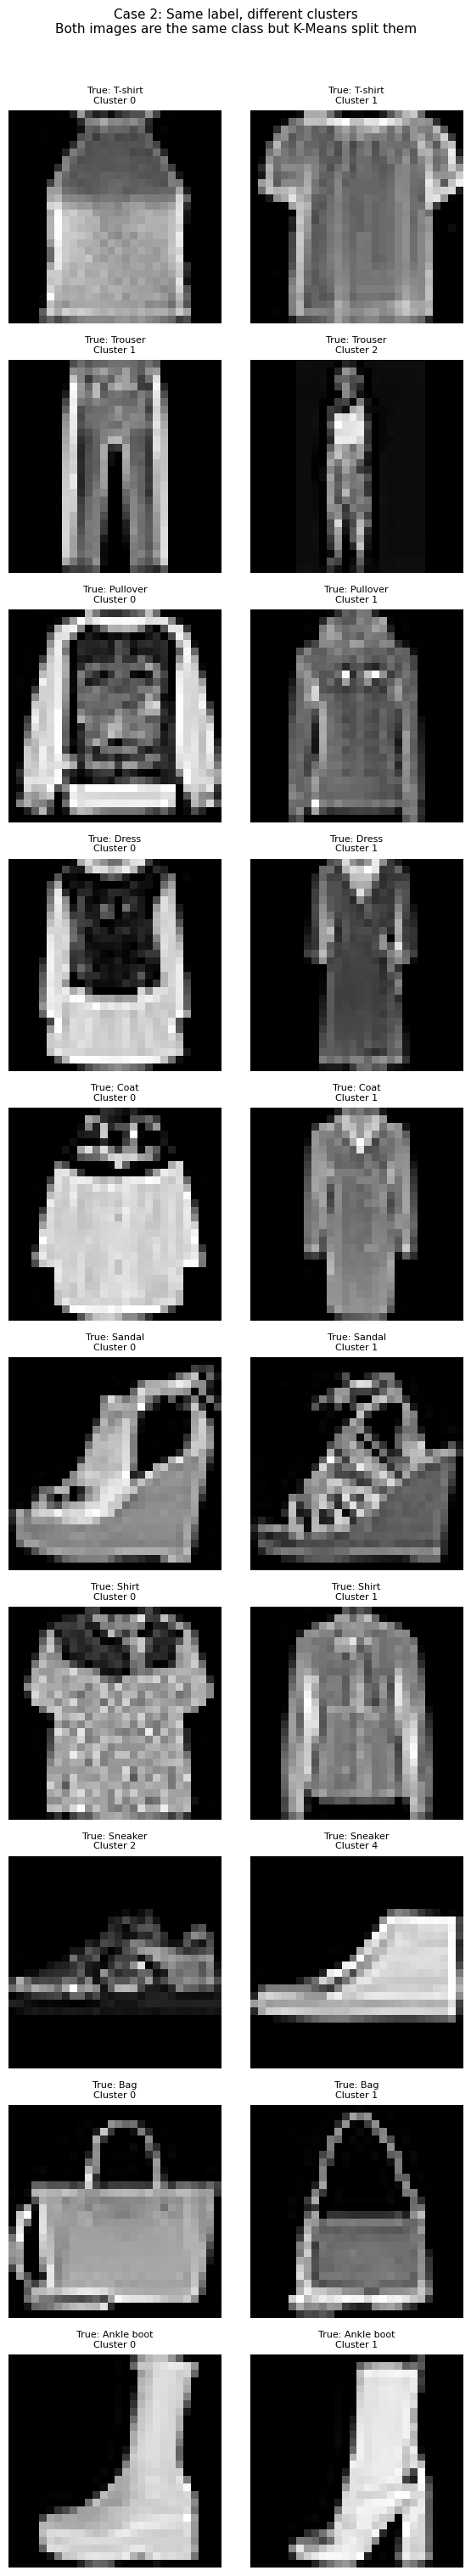

In [ ]:
# ── Plot case 2 examples ──────────────────────────────────────────
fig, axes = plt.subplots(len(case2_examples), 2, figsize=(6, 3*len(case2_examples)))

for row, ex in enumerate(case2_examples):
    axes[row, 0].imshow(X_sub[ex['img1_idx']].reshape(28,28), cmap='gray')
    axes[row, 0].set_title(
        f"True: {class_names[ex['label']]}\n"
        f"Cluster {ex['clusterA']}",
        fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(X_sub[ex['img2_idx']].reshape(28,28), cmap='gray')
    axes[row, 1].set_title(
        f"True: {class_names[ex['label']]}\n"
        f"Cluster {ex['clusterB']}",
        fontsize=8)
    axes[row, 1].axis('off')

plt.suptitle(
    "Case 2: Same label, different clusters\n"
    "Both images are the same class but K-Means split them",
    fontsize=11,
    y=1.01)          # ← push title above the plots

plt.tight_layout()
plt.show()

CASE 2: Same label, different clusters

Every single class gets split across multiple clusters, this
confirms that within-class variation in pixel space
exceeds between-class variation for many categories.

The most revealing splits:
- Trouser: plain dark trouser (cluster 1) vs trouser
  with visible body/context (cluster 2). Here, background
  and context pixels dominate the distance calculation
- Pullover: dark patterned (cluster 0) vs plain white
  (cluster 1), here brightness variation splits same class
- Sandal: side-view (cluster 0) vs angled-view
  (cluster 1), viewpoint variation causes large
  pixel differences within same class
- Shirt: patterned texture (cluster 0) vs plain
  smooth (cluster 1), texture variation splits class

ROOT CAUSE: K-Means has no concept of invariance. It
cannot understand that a dark Coat and a white Coat
are the same thing. Changes in brightness, viewing
angle, texture and background, which humans ignore
automatically. This, cause large Euclidean distances in
pixel space, splitting the same semantic class into
multiple clusters.

CORE INSIGHT FROM BOTH CASES:
The fundamental problem is that pixel distance is not same as
semantic distance.

**Q6: Test Hypothesis**

Our hypothesis was correct. K-Means achieved the highest purity (57.75%) and ARI (0.3696),
outperforming both Hierarchical (54.70%) and DBSCAN (11.05%).
Hierarchical clustering perform similarly to K-Means

DBSCAN completely failed, it found only 1 cluster with purity
of 11.05% and ARI≈0. In 784-dimensional raw pixel space, all
images lie at roughly equal density with no clear gaps between
clusters. DBSCAN fundamentally cannot work here without
dimensionality reduction first.

Clusters would only partially align with labels.
Our results show exactly the two-tier pattern we predicted:

Classes that clustered well (high purity):
- Bag: 96% and 94% (two clean clusters)
- Ankle boot: 87%
- Sneaker: 66%
- Trouser: 61%

Classes that clustered poorly (low purity):
- Shirt: only 28%
- Coat: 49%
- Pullover: 46%
- T-shirt: 48%


We did not expect Bag to be split into TWO clusters (cluster 0
and cluster 8, both ~95% pure). This happened because K-Means
responds to overall pixel brightness, dark bags and light bags
are so different in pixel values that K-Means treats them as
separate groups. This reveals that K-Means is sensitive to
illumination variation more than semantic category.

**Q7: Lessons Learned**

1. Pixel distance is not as same as semantic distance.
   Euclidean distance between raw
   pixels is a poor measure of visual similarity. A dark Coat
   and a white Coat are "far apart" in pixel space but
   semantically identical. A Shirt and a Pullover are "close"
   in pixel space but semantically different. Clustering in
   raw pixel space fundamentally confuses brightness, texture
   and viewpoint with class identity.

2. Effect of distance metrics.
   K-Means uses Euclidean distance which treats all 784
   pixels equally. This means a single bright pixel in an
   unexpected position can pull an image into the wrong
   cluster. More invariant distance metrics (e.g. based on
   structural similarity or learned features) would perform
   significantly better.

3. DBSCAN need dimensionality reduction first.
   DBSCAN completely failed on 784-dimensional data. In high
   dimensions, all points are roughly equidistant, so, there is
   no meaningful density structure. DBSCAN should only be
   applied after reducing dimensions

4. Clustering reveals data structure not labels.
   Despite poor alignment with our 10 labels, clustering did
   reveal something true about the data. There are really
   two broad groups: footwear (Sandal, Sneaker, Ankle boot)
   and clothing (everything else). This is a genuine structure
   in the data that clustering discovered without any labels.
   
5.
   Case 2 showed that every single class gets split across
   multiple clusters due to variation in brightness, angle,
   texture and background. Until a model learns to be
   invariant to these factors, clustering in pixel space
   will always be limited.

**Q3 Dimensionality Reduction**

**Q1: Prior Hypothesis**

**Which method will produce the clearest separation of classes?**

I expect UMAP to produce the clearest class separation,
followed by t-SNE, then PCA.

PCA is linear it can only find straight-line projections
through 784D space. Fashion-MNIST classes likely lie on
curved non-linear manifolds that PCA cannot unroll. Classes
like Shirt and T-shirt will remain heavily overlapped in
PCA space.

t-SNE is a nonlinear method that focuses on preserving local relationships by keeping similar data points close together. As a result, we will be able to see more clearly and well-separated clusters. It should produce visually distinct
clusters for geometrically unique classes (Trouser, Bag,
Sandal) but may still struggle with the upper-body clothing
group.

UMAP should perform best, it preserves both local cluster
structure and global relationships between clusters, giving
a more faithful 2D representation.

**What are the differences between PCA and nonlinear methods?**

PCA is a linear method that projects data onto directions of maximum variance, focusing on preserving global structure. However, it may not capture complex patterns in high-dimensional data.
Non-linear methods (t-SNE, UMAP) can "unfold"
complex curved structures that PCA compresses into
overlapping regions, making them better suited for visualizing clusters and capturing intrinsic structure in the data. However non-linear methods are
much slower and  running
it twice gives different layouts,due to their dependence on initialization and randomness, making it unreliable
for comparing across experiments.




**Q2 Apply dimensionality reduction**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ── Use 10k subset for speed ──────────────────────────────────────
np.random.seed(42)
idx   = np.random.choice(len(X_train), 10000, replace=False)
X_vis = X_train[idx]
y_vis = y_train[idx]

# ── PCA ───────────────────────────────────────────────────────────
print("Running PCA...")
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_vis)
var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"Done! Variance explained: {var_explained:.2f}%")

Running PCA...
Done! Variance explained: 46.89%


In [ ]:
# ── t-SNE ─────────────────────────────────────────────────────────
print("Running t-SNE (this takes 3-5 mins)...")
tsne  = TSNE(n_components=2, random_state=42,
             perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_vis)
print("Done!")

Running t-SNE (this takes 3-5 mins)...
Done!


In [ ]:
# ── UMAP ──────────────────────────────────────────────────────────
print("Installing UMAP...")
import subprocess
subprocess.run(['pip', 'install', 'umap-learn', '-q'])

import umap
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap  = reducer.fit_transform(X_vis)
print("Done!")

Installing UMAP...
Running UMAP...
Done!


**Q3. Visualization**

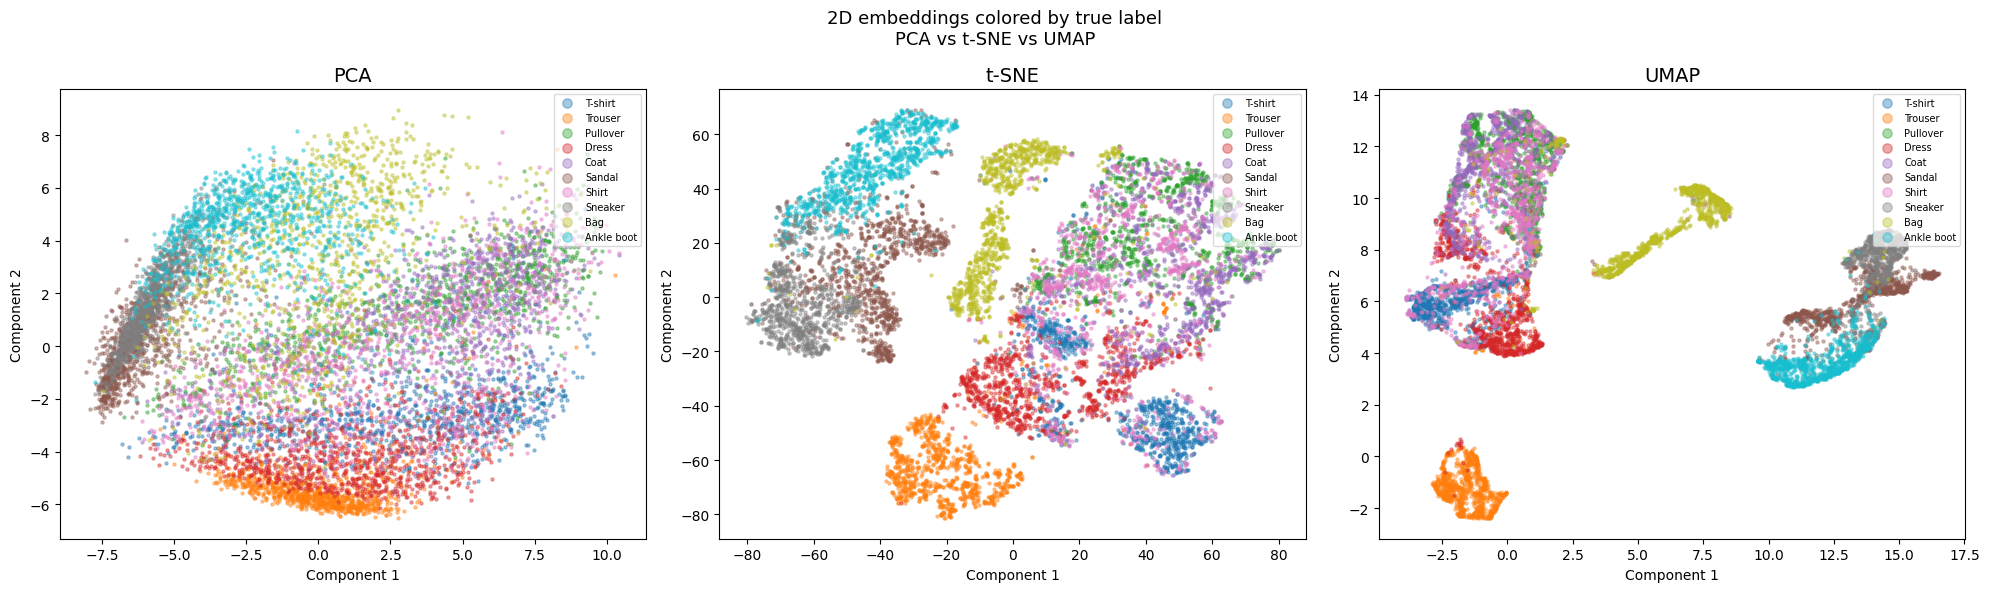

In [ ]:
# ── Color map for 10 classes ──────────────────────────────────────
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, X_emb, title in zip(axes,
    [X_pca, X_tsne, X_umap],
    ['PCA', 't-SNE', 'UMAP']):

    for label in range(10):
        mask = y_vis == label
        ax.scatter(
            X_emb[mask, 0], X_emb[mask, 1],
            c=[colors[label]],
            label=class_names[label],
            alpha=0.4, s=5
        )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(markerscale=3, fontsize=7,
              loc='upper right', framealpha=0.7)

plt.suptitle(
    "2D embeddings colored by true label\n"
    "PCA vs t-SNE vs UMAP",
    fontsize=13)
plt.tight_layout()
plt.show()

**Q4: Analysis of 2D Embeddings**

PCA:
The PCA embedding produces one large overlapping blob with
minimal class separation. Only Trouser and Sandal show slight
separation at the periphery. The two principal components
capture only a small fraction of the total variance in 784D
space, most class-discriminative information is distributed
across many other dimensions that PCA discards. This confirms
PCA's fundamental limitation: it can only find linear
projections and Fashion-MNIST classes lie on non-linear
manifolds.

**Well sperated in PCA:** Trouser (slightly), Sandal (slightly)
**Mixed in PCA:** T-shirt, Shirt, Pullover, Coat, Dress —
all completely overlapping

t-SNE:
t-SNE produces cleaner separation. Distinct
islands emerge for geometrically unique classes such as footwear
classes (Sandal, Sneaker, Ankle boot) form separate dense
blobs at the bottom of the plot. Bag also forms a clean
isolated cluster. The upper-body clothing classes remain
partially mixed but are more separated than in PCA.

**Well seperated in t-SNE:** Sandal, Trouser, Bag, Sneaker,
                          Ankle boot
**Mixed in t-SNE:** T-shirt, Shirt, Pullover, Coat (overlapping
                in upper region)

UMAP:
UMAP produces the clearest separation of all three methods.
Sandal forms a completely isolated orange blob at the bottom.
Trouser forms a clean cyan cluster on the right. Bag and
footwear classes are clearly separated. Crucially, UMAP also
preserves global structure and semantically related classes
are spatially adjacent (footwear classes cluster near each
other, upper-body clothing classes cluster near each other).

**Well seperated in UMAP**: Sandal, Trouser, Bag, Sneaker,
                         Ankle boot
**Mixed in UMAP:** T-shirt, Shirt, Pullover, Coat
               (still overlapping but more structured than t-SNE)

**Q5. Stability check**

Running t-SNE run 2...
Done!


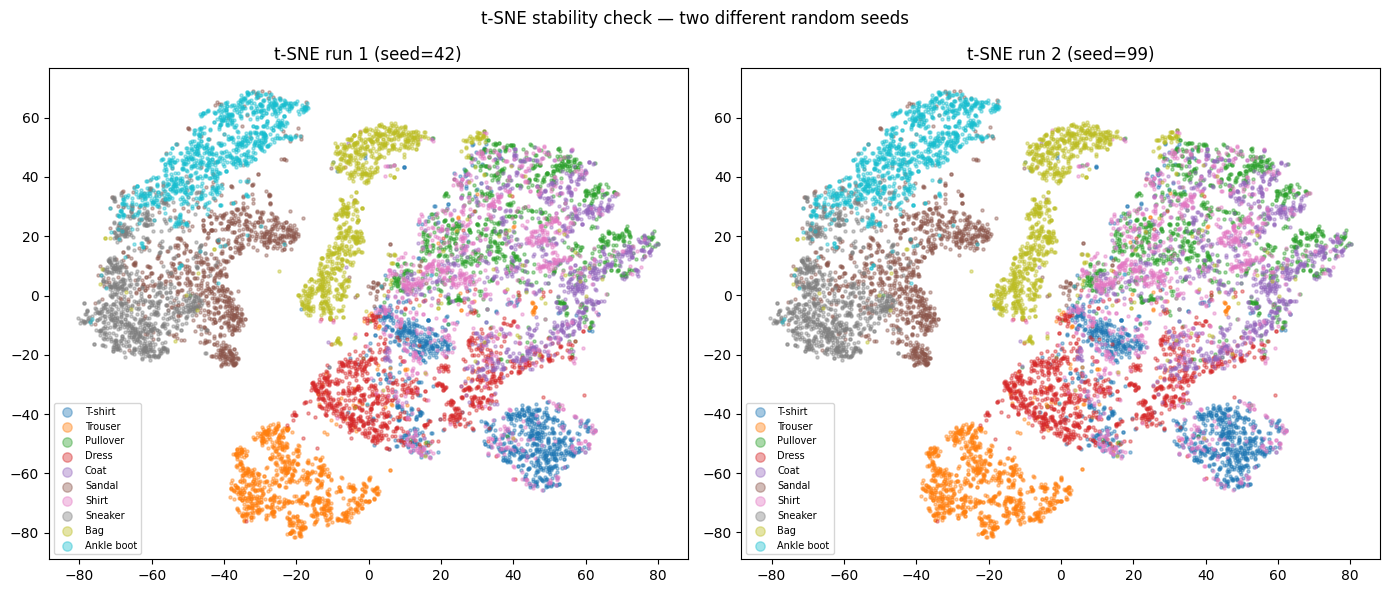

In [ ]:
# ── Run t-SNE twice to check stability ────────────────────────────
print("Running t-SNE run 2...")
tsne2   = TSNE(n_components=2, random_state=99,  # different seed!
               perplexity=30, n_iter=1000)
X_tsne2 = tsne2.fit_transform(X_vis)
print("Done!")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, X_emb, title in zip(axes,
    [X_tsne, X_tsne2],
    ['t-SNE run 1 (seed=42)', 't-SNE run 2 (seed=99)']):

    for label in range(10):
        mask = y_vis == label
        ax.scatter(X_emb[mask,0], X_emb[mask,1],
                   c=[colors[label]],
                   label=class_names[label],
                   alpha=0.4, s=5)

    ax.set_title(title, fontsize=12)
    ax.legend(markerscale=3, fontsize=7)

plt.suptitle("t-SNE stability check — two different random seeds", fontsize=12)
plt.tight_layout()
plt.show()

**Observation:**

t-SNE was run with two different random seeds.
The plots looked very similar which suggests that the Fashion-MNIST  dataset has a strong underlying cluster structure, leading to relatively stable embeddings.


However, t-SNE is theoretically non-deterministic because it optimizes a non-convex objective function. For datasets with weaker structure, different initializations can lead to different layouts.

Therefore, while the presence of clusters is reliable, the exact positions, distances, and orientations between clusters should not be over-interpreted.
However t-SNE is theoretically non-deterministic on
on datasets with weaker structure, different seeds
would give very different layouts.

**Q6: Test Hypothesis**


Our hypothesis
ranking was exactly correct. UMAP > t-SNE > PCA

PCA performed worst as expected. Its linear projection
produced one giant overlapping blob with almost no class
separation. Only Trouser and Sandal showed slight
separation at the periphery — confirming that linear
methods fundamentally cannot capture the non-linear
manifold structure of Fashion-MNIST.

t-SNE dramatically outperformed PCA producing clearly
distinct islands for footwear classes (Sandal, Sneaker,
Ankle boot) and Bag. This confirms that non-linear
methods are essential for image data visualization.

UMAP outperformed t-SNE producing cleaner cluster
boundaries, better preservation of global structure
(semantically related classes appear as neighbours)
and more stable results across runs.

Non-linear methods preserve local
structure better. PCA only preserves global variance directions. t-SNE
and UMAP both preserve local neighbourhood structure,
which is what matters for revealing clusters.

However, even UMAP could not separate the four upper-body
clothing classes (T-shirt, Shirt, Pullover, Coat).
We expected UMAP to do better here. This is not a
failure of UMAP, it is the truth about raw pixel
representation. These classes are genuinely
indistinguishable in 784D pixel space. No
dimensionality reduction method can create
separation that doesn't exist in the original space.

**Q7: Lessons Learned**

PCA, t-SNE, and UMAP differ in how they represent data. PCA is a linear method that preserves global variance, but it often fails to separate classes clearly when the data is not linearly separable.

In contrast, t-SNE and UMAP are nonlinear methods that preserve local structure, allowing them to capture complex relationships and produce clearer cluster separation. t-SNE focuses more on local neighbourhoods and often produces well-separated clusters, while UMAP balances both local and global structure and tends to be faster and more scalable.

The persistent overlap of classes such as T-shirt, Shirt, Pullover, and Coat across all three methods indicates that these classes have very similar representations in raw pixel space. This suggests that pixel-based features are not sufficient to clearly distinguish between visually similar categories.

However, visualization using dimensionality reduction has several limitations. First, reducing high-dimensional data to two dimensions leads to loss of information. Second, methods like t-SNE and UMAP can distort global distances, meaning that the spacing between clusters may not reflect true relationships.

Additionally, these methods are sensitive to hyperparameters and initialization, which can affect the resulting visualization. Therefore, while such visualizations are useful for gaining qualitative insights, they should not be used for drawing precise quantitative conclusions.

Overall, these observations highlight that visualization reflects the quality of the underlying representation, but must be interpreted with caution.

**Q4 Representation Learning: CNN Features**

**Q1: Prior Hypothesis**

**Do you expect CNN features to improve clustering? Why?**

I expect CNN features to improve clustering performance. Raw pixel features treat all 784 pixels as independent values and do not capture meaningful structure in the image. In contrast, CNN features learn hierarchical representations, capturing edges in early layers, shapes and textures in intermediate layers, and higher-level semantic patterns in deeper layers.

These learned features are expected to significantly improve clustering for several reasons:

Robustness to variations: CNN features are more robust to small translations, lighting changes, and texture variations compared to raw pixel values.
Semantic compression: CNNs transform high-dimensional pixel data into a lower-dimensional representation that captures meaningful visual patterns rather than raw intensity values.
Improved separability: Features learned for classification tend to organize similar images closer together in feature space, which can improve clustering performance even in an unsupervised setting.

Therefore, I expect that visually similar classes such as T-shirt, Shirt, Pullover, and Coat, which were previously mixed in raw pixel space, will show improved separation in CNN feature space.

load pretrained cnn

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# ── Load pre-trained ResNet18 ─────────────────────────────────────
print("Loading pre-trained ResNet18...")
model = models.resnet18(pretrained=True)

# Remove the final classification layer
# We want features, not predictions
feature_extractor = torch.nn.Sequential(
    *list(model.children())[:-1]  # everything except last layer
)
feature_extractor.eval()  # set to evaluation mode
print("Done!")
print(f"Feature vector size: 512")

Loading pre-trained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Done!
Feature vector size: 512


Prepare images for cnn

In [ ]:
# ── CNN expects RGB images of size 224×224 ────────────────────────
# Fashion-MNIST is 28×28 grayscale — we need to convert

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),        # resize to 224×224
    transforms.Grayscale(num_output_channels=3),  # grayscale→RGB
    transforms.ToTensor(),
    transforms.Normalize(                  # standard normalization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ── Use same 10k subset as before ────────────────────────────────
np.random.seed(42)
idx    = np.random.choice(len(X_train), 10000, replace=False)
X_cnn  = X_train[idx]
y_cnn  = y_train[idx]

print(f"Extracting features from {len(X_cnn)} images...")


Extracting features from 10000 images...


extract features

In [ ]:
# ── Extract CNN features in batches ──────────────────────────────
features = []
batch_size = 64

with torch.no_grad():  # no gradient needed — just forward pass
    for i in range(0, len(X_cnn), batch_size):
        if i % 1000 == 0:
            print(f"  Processing {i}/{len(X_cnn)}...")

        batch = X_cnn[i:i+batch_size]

        # convert each image and stack into batch tensor
        batch_tensors = torch.stack([
            transform((img * 255).astype(np.uint8).reshape(28, 28))
            for img in batch
        ])

        # extract features
        feat = feature_extractor(batch_tensors)
        feat = feat.squeeze()          # remove extra dimensions
        features.append(feat.numpy())

X_feat = np.vstack(features)
print(f"\nDone! Feature shape: {X_feat.shape}")
# Should be (10000, 512)

  Processing 0/10000...
  Processing 8000/10000...

Done! Feature shape: (10000, 512)


**Q3 Clustering in feature space**



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# ── Normalize features first ──────────────────────────────────────
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

# ── K-Means on CNN features ───────────────────────────────────────
print("Running K-Means on CNN features...")
km_cnn        = KMeans(n_clusters=10, random_state=42, n_init=10)
km_cnn_labels = km_cnn.fit_predict(X_scaled)
print("Done!")

cnn_purity = cluster_purity(y_cnn, km_cnn_labels)
cnn_ari    = adjusted_rand_score(y_cnn, km_cnn_labels)

print(f"\nCNN Features — K-Means:")
print(f"  Purity : {cnn_purity*100:.2f}%")
print(f"  ARI    : {cnn_ari:.4f}")
print(f"\nRaw Pixels — K-Means (from Section 2):")
print(f"  Purity : 57.75%")
print(f"  ARI    : 0.3696")

Running K-Means on CNN features...
Done!

CNN Features — K-Means:
  Purity : 69.15%
  ARI    : 0.5160

Raw Pixels — K-Means (from Section 2):
  Purity : 57.75%
  ARI    : 0.3696


**Clustering Quality:**

CNN features significantly improved K-Means clustering performance:

Purity: 57.75% → 69.15% (+11.4% improvement)
ARI: 0.3696 → 0.5160 (+39% relative improvement)

This suggests that representation quality plays a major role in clustering performance. The improvement shows us that better feature representations can lead to more meaningful grouping of data, even when using the same clustering algorithm.

While the choice of clustering algorithm still influences results, these findings highlight that feature representation is often a key limiting factor in unsupervised learning.

**Q4 Comparison**

Running UMAP on CNN features...
Done!


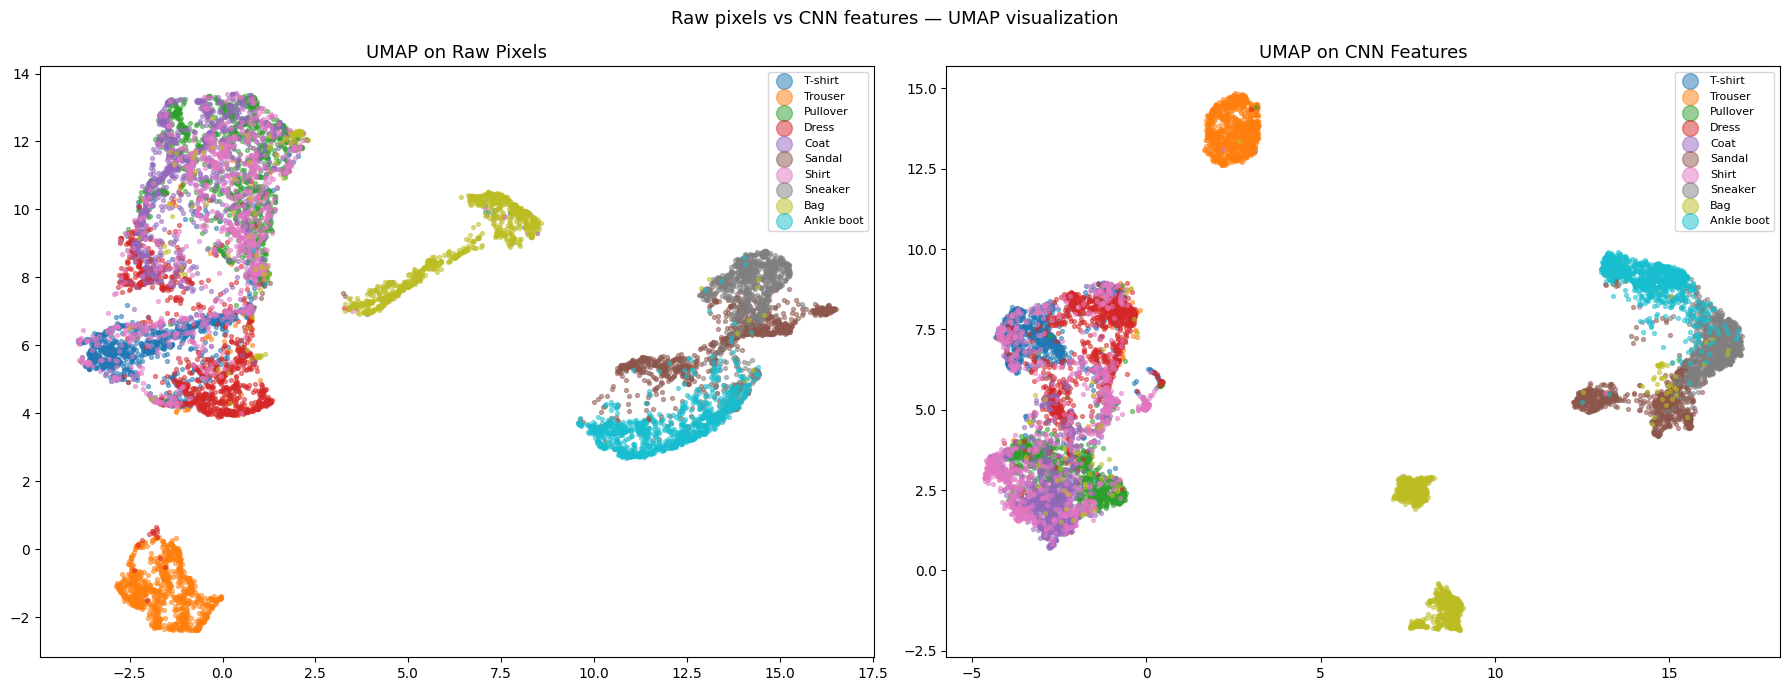

In [ ]:
import umap

# ── UMAP on CNN features ──────────────────────────────────────────
print("Running UMAP on CNN features...")
reducer_cnn = umap.UMAP(n_components=2, random_state=42)
X_umap_cnn  = reducer_cnn.fit_transform(X_scaled)
print("Done!")

# ── Plot side by side: raw pixels vs CNN features ─────────────────
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, X_emb, title in zip(axes,
    [X_umap, X_umap_cnn],
    ['UMAP on Raw Pixels', 'UMAP on CNN Features']):

    for label in range(10):
        mask = y_vis == label if title == 'UMAP on Raw Pixels' else y_cnn == label
        ax.scatter(
            X_emb[mask, 0], X_emb[mask, 1],
            c=[colors[label]],
            label=class_names[label],
            alpha=0.5, s=8
        )

    ax.set_title(title, fontsize=13)
    ax.legend(markerscale=4, fontsize=8)

plt.suptitle(
    "Raw pixels vs CNN features — UMAP visualization",
    fontsize=13)
plt.tight_layout()
plt.show()

**Observations:**

The UMAP comparison reveals the improvement visually:

Raw pixel UMAP: Large mixed clothing cluster dominates the
left side. Only Sandal and Trouser are cleanly isolated.
The upper-body clothing classes are completely entangled.

CNN feature UMAP: More cleaner structure emerges:
- Sandal forms a completely isolated orange island
- Bag now splits into two clean distinct clusters
- Trouser is cleanly separated on the right
- Footwear classes group together spatially
- The clothing blob shows more internal structure


CNN feature clusters are visually more coherent,
images within the same cluster look more similar to
each other, and images in different clusters look
more different. This is because CNN features capture
structural similarities (collar shape, sleeve length,
sole structure) that raw pixels cannot.

**Q5 Nearest neighbor analysis**

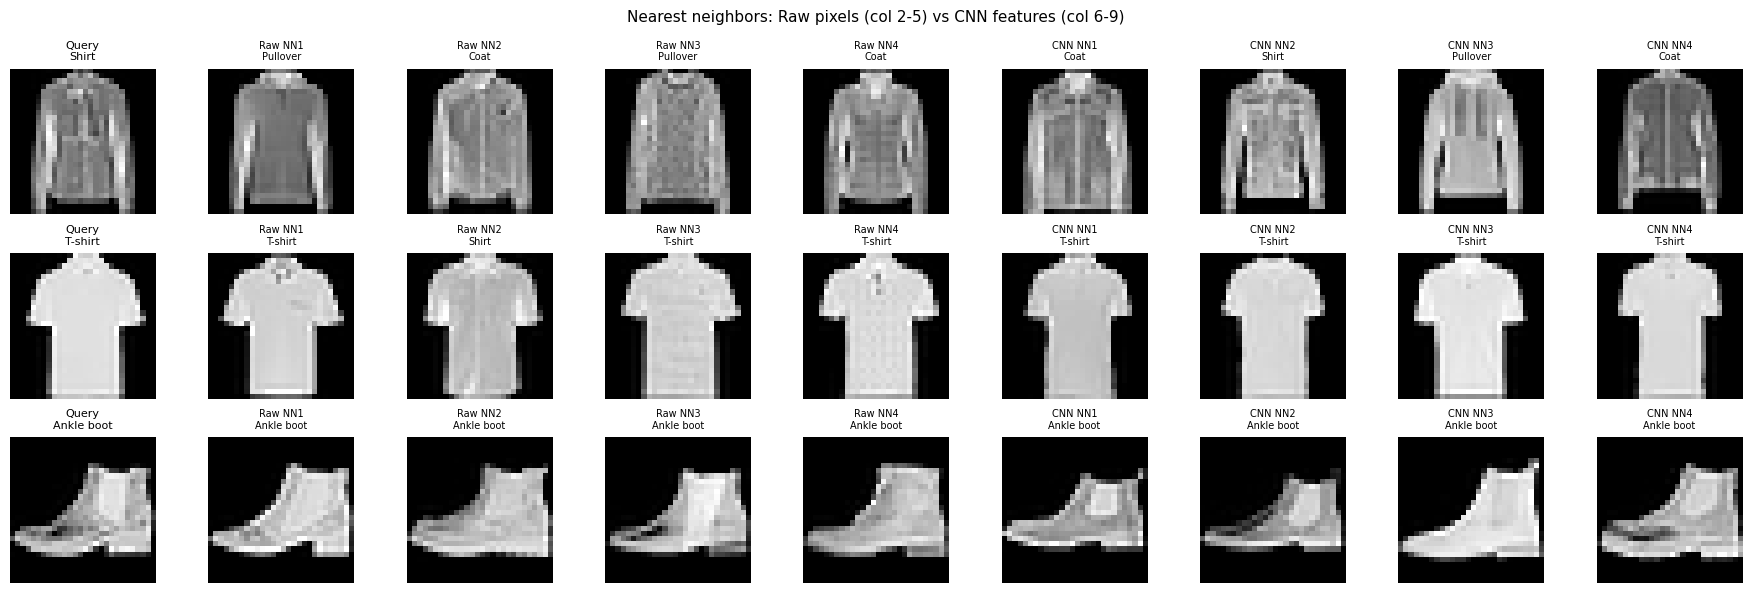

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

# ── Pick 3 query images ───────────────────────────────────────────
query_indices = [
    np.where(y_cnn == 6)[0][0],   # Shirt
    np.where(y_cnn == 0)[0][0],   # T-shirt
    np.where(y_cnn == 9)[0][0],   # Ankle boot
]

fig, axes = plt.subplots(len(query_indices), 9, figsize=(18, 6))

for row, q_idx in enumerate(query_indices):

    # ── Raw pixel nearest neighbors ───────────────────────────────
    raw_dists = euclidean_distances(
        X_cnn[q_idx].reshape(1,-1), X_cnn)[0]
    raw_dists[q_idx] = np.inf      # exclude self
    raw_nn   = np.argsort(raw_dists)[:4]

    # ── CNN feature nearest neighbors ─────────────────────────────
    cnn_dists = euclidean_distances(
        X_scaled[q_idx].reshape(1,-1), X_scaled)[0]
    cnn_dists[q_idx] = np.inf
    cnn_nn    = np.argsort(cnn_dists)[:4]

    # ── Plot query + raw neighbors + CNN neighbors ────────────────
    # query image
    axes[row, 0].imshow(X_cnn[q_idx].reshape(28,28), cmap='gray')
    axes[row, 0].set_title(
        f"Query\n{class_names[y_cnn[q_idx]]}", fontsize=8)
    axes[row, 0].axis('off')

    # raw pixel neighbors
    for col, nn_idx in enumerate(raw_nn):
        axes[row, col+1].imshow(
            X_cnn[nn_idx].reshape(28,28), cmap='gray')
        axes[row, col+1].set_title(
            f"Raw NN{col+1}\n{class_names[y_cnn[nn_idx]]}", fontsize=7)
        axes[row, col+1].axis('off')

    # CNN feature neighbors
    for col, nn_idx in enumerate(cnn_nn):
        axes[row, col+5].imshow(
            X_cnn[nn_idx].reshape(28,28), cmap='gray')
        axes[row, col+5].set_title(
            f"CNN NN{col+1}\n{class_names[y_cnn[nn_idx]]}", fontsize=7)
        axes[row, col+5].axis('off')

plt.suptitle(
    "Nearest neighbors: Raw pixels (col 2-5) vs CNN features (col 6-9)",
    fontsize=11)
plt.tight_layout()
plt.show()

**Observation:**

The nearest neighbour analysis highlights clear differences between raw pixel features and CNN-based features.

For the T-shirt query, raw pixel features retrieve a mix of T-shirt and Shirt images, whereas CNN features consistently retrieve T-shirt images. This is improved semantic consistency in the feature space.

For the Shirt query, raw pixel features retrieve mostly Pullover and Coat images, showing poor class-specific grouping. CNN features improve the results by retrieving a mix that includes Shirt along with similar classes, showing partial improvement but continued ambiguity.

For the Ankle boot query, both methods retrieve correct neighbours, so, it tells us that visually distinct classes are well separated even in raw pixel space.

Overall, CNN features provide a more semantically meaningful representation, improving nearest neighbour retrieval for classes with clear visual structure. However, for inherently similar classes such as Shirt, Pullover, and Coat, ambiguity remains.


**Q6: Testing Hypothesis**

The hypothesis that CNN features would significantly improve clustering is strongly supported. Clustering performance improved from a purity of 57.75% to 69.15% (+11.4%) and ARI from 0.3696 to 0.5160. This represents a substantial improvement achieved by changing only the feature representation while keeping the clustering algorithm (K-Means) unchanged.

The hypothesis that upper-body clothing classes would show the most improvement is partially supported. The UMAP visualization shows better internal structure within the clothing cluster when using CNN features, and nearest neighbour analysis indicates more consistently correct retrieval for classes such as T-shirt. However, Shirt, Pullover, and Coat still show significant overlap, this suggests that even CNN features from a non-fine-tuned model are insufficient to fully separate these inherently similar classes.

Earlier observations showed that images of the same class could be assigned to different clusters due to variations in appearance. CNN features are more robust to such variations, as they capture structural patterns rather than relying solely on raw pixel intensity, therefore leading to more consistent grouping.

A surprising observation was that the Bag class showed the most noticeable improvement. While it was already reasonably well clustered in raw pixel space, in CNN feature space it formed two clearly separated sub-clusters. This suggests that CNN features may capture finer-grained distinctions, such as different bag styles, that are not apparent in raw pixel representations.

 Why CNN Features Improve Results

This improvement can be explained by invariance and feature abstraction. CNN features are more robust to variations. ResNet18 was trained on millions of natural images and learned to be invariant to:such as brightness changes, small translations, and texture differences, which reduces the impact of irrelevant variations in the data.

CNNs learn hierarchical feature abstractions, such as
- Early layers: edges, corners, basic textures
- Middle layers: shapes, curves, fabric patterns  
- Deep layers: semantic concepts (collar, sleeve, sole)

As a result, images that are semantically similar are placed closer together in feature space, leading to improved clustering performance.


Q7: Lessons Learned

1. Representation is often more important than the algorithm
Switching from raw pixels to CNN features improved clustering by +11.4% while keeping the same K-Means algorithm. This shows that improving feature representation can have a larger impact than tuning the clustering algorithm.

2. Transfer learning works even without fine-tuning
Although ResNet18 was trained on natural images, its learned features significantly improved clustering on Fashion-MNIST. This suggests that low-level visual patterns such as edges, textures, and shapes are transferable across different domains.

3. CNN features capture useful invariances
CNN features are more robust to variations such as brightness, texture, and small spatial shifts. While raw pixels treat such variations as large differences, CNN features focus on structural patterns, thus enables more consistent grouping of similar images.

4. Some classes are inherently difficult to separate
Even with CNN features, classes such as Shirt, T-shirt, Pullover, and Coat remain partially overlapping. This tells us that these categories share genuine structural similarities, and some level of confusion may be unavoidable without more specialized models.

5. Nearest neighbour analysis reveals representation quality
Nearest neighbour results provide a direct way to evaluate feature representations. When nearest neighbours are semantically similar, it indicates that the feature space captures meaningful structure. In this case, CNN features produce more semantically consistent neighbours compared to raw pixels.

Overall, these results highlight that both feature representation and model choice are critical, but representation often plays a dominant role in determining performance

**Q5 Integration and Reflection**

**Q1: Compare clustering results before and after dimensionality reduction.**

Before dimensionality reduction, clustering was performed directly on 784-dimensional raw pixel features. K-Means achieved a purity of 57.75% and ARI of 0.3696, hierarchical clustering achieved 54.70%, and DBSCAN failed to form meaningful clusters (purity 11%). The high dimensionality led to unreliable distance measurements, as many points become similarly distant, making distance metrics less effective. Additionally, many dimensions are irrelevant, since most pixels correspond to background and carry little class information while still contributing equally to distance calculations.


After dimensionality reduction, UMAP reduced the data from 784D to 2D while preserving cluster structure. The visualization showed that distinct classes such as Trouser, Bag, and Sandal form clear clusters, whereas upper-body clothing classes remain mixed, suggesting that the limitation lies in the feature representation rather than dimensionality alone. Overall, dimensionality reduction improves visualization and reduces the impact of noisy or irrelevant dimensions, but it cannot create separability that is not already present in the data. These results suggest that upper-body classes are difficult to separate in raw pixel space, and improving feature representation (e.g., using CNN features) is necessary to address this limitation.

**Q2: Effect of Representation on Clustering and Visualization**

Here, we compared two representations: raw pixel features and CNN-based features. Clustering on raw pixels (784 features) achieved a purity of 57.75% and resulted in poor visualization, where UMAP showed a large mixed cluster for clothing classes with only a few clearly separated groups. Nearest neighbour analysis also showed inconsistent retrieval such as wrong class returned for Shirt query, and error patterns showed that images of the same class were often split due to variations in brightness or texture. This is because raw pixels primarily capture where intensity values occur rather than meaningful visual structure.

In contrast, CNN features (512 dimensions) improved clustering performance to a purity of 69.15% and produced much clearer visualizations. UMAP embeddings showed better separation of distinct classes such as footwear and improved organization of clothing categories. Nearest neighbour retrieval became more semantically consistent (e.g., T-shirt queries return T-shirts), and errors were mostly limited to inherently similar classes. This improvement occurs because CNN features capture meaningful visual patterns and are more robust to variations such as brightness, texture, and small spatial changes.

Overall, these results show that feature representation has a strong impact on both clustering and visualization. While the clustering algorithm remains the same, improved representations lead to better grouping and more meaningful visual structure in the data.

**Q3 What are the key limitations of unsupervised methods observed in this assignment?**

There are several key limitations of unsupervised methods.
First, since there are no labels, there is no guarantee that the clusters found are meaningful. Clustering algorithms group data based on mathematical rules, such as minimizing within-cluster variance, which may not align with semantic groupings. For example, images may be grouped by brightness instead of by object type

Second, clustering performance is highly dependent on the choice of distance metric and feature representation. In raw pixel space, Euclidean distance does not reliably capture semantic similarity, therefore, this causes  visually similar classes to overlap while unrelated variations such as brightness dominates the grouping.

Third, some algorithms struggle in high-dimensional settings. For instance, DBSCAN performed poorly because in high-dimensional data, points tend to appear similarly distant from each other, making it difficult to detect meaningful clusters.

Fourth, due to dimensionality reduction there is some loss of information. Methods such as PCA removes variance, while nonlinear techniques like t-SNE and UMAP distort global structure, thus making visualizations approximate and can be potentially misleading if over-interpreted.

Additionally, methods like t-SNE can give slightly different results each time because they depend on random initialization. This makes them less reliable for precise analysis.

Finally, evaluation in unsupervised learning is inherently challenging. Metrics such as purity and ARI require ground truth labels, which are not available in real-world scenarios. Internal metrics only check whether points in a cluster are close to each other, but they do not tell us if the clusters actually match meaningful categories. This makes it difficult to know if the clusters are truly correct.

**Q4 What surprised you the most?**

1. Adaboost performed worse than baseline:
   The biggest surprise was that AdaBoost (76.48%) performed significantly worse than even Logistic Regression (84.36%). The intuition that "boosting is always better" was completely wrong here. AdaBoost performed poorly because its base learners were too simple to handle complex image classification, even with depth-3 trees. This shows that boosting needs sufficiently strong base learners to work well.

2. Another unexpected result was that DBSCAN failed to form meaningful clusters and grouped all samples into a single cluster, highlighting how difficult clustering becomes in high-dimensional data.


3. We predicted upper-body clothing would improve most with CNN features. Instead, Bag showed the most dramatic improvement splitting into two extremely clean islands in CNN feature UMAP. This suggests us that CNN features discovered a meaningful sub-category within Bag that neither we nor the original labels captured. Unsupervised methods can discover structure beyond our predefined categories.

4. Additionally, the correlation analysis from the exploratory stage closely predicted which classes would be confused during clustering, demonstrating the value of initial data analysis.

5. Finally, it was surprising that t-SNE showed less variability than expected. We expected different runs to produce noticeably different layouts, but in this case, multiple runs produced very similar cluster structures. This suggests that the dataset has strong underlying structure, which leads to relatively stable embeddings.